### Tissera Ana Paula - `Notebook TP4`

In [308]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


##### Imports

In [309]:
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import os
import pandas as pd

In [310]:
# uso de cupy en vez de numpy para correrlo en GPU
import cupy as cp

device_id = cp.cuda.Device().id
device_name = cp.cuda.runtime.getDeviceProperties(device_id)['name']

print(f"Usando GPU {device_id}: {device_name}")

Usando GPU 0: b'NVIDIA GeForce RTX 3050 Laptop GPU'


In [311]:
SEED = 42

## `1.` **Clustering de datos**

##### Cargar los datos

In [312]:
clustering_path = "data/clustering.csv"
clustering_df = pd.read_csv(clustering_path)


##### Visualización de ejemplo

In [313]:
clustering_df.sample(5, random_state=SEED)

,Unnamed: 0,A,B
84,84,822368,648690
2470,2470,954037,754046
2804,2804,640123,716370
4987,4987,772586,123935
4924,4924,598444,128607


In [314]:
clustering_df = clustering_df.drop(clustering_df.columns[0], axis=1)

In [315]:
clustering_df.sample(5, random_state=SEED)

,A,B
84,822368,648690
2470,954037,754046
2804,640123,716370
4987,772586,123935
4924,598444,128607


In [316]:
X_cpu = clustering_df.values
X = cp.array(X_cpu)  # pasar a GPU
X = cp.array(clustering_df.values)

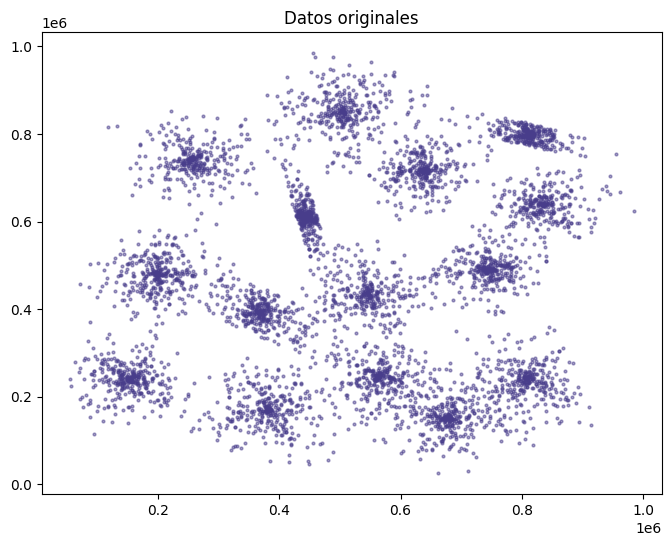

In [317]:
plt.figure(figsize=(8, 6))
plt.plot(X_cpu[:, 0], X_cpu[:, 1], "o", markersize=2, alpha=0.5, color = "darkslateblue")
plt.title("Datos originales")
plt.show()

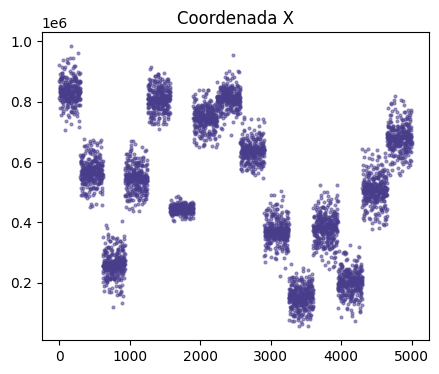

In [318]:
plt.figure(figsize=(5, 4))
plt.plot(X_cpu[:, 0], "o", markersize=2, alpha=0.5, color = "darkslateblue")
plt.title("Coordenada X")
plt.show()

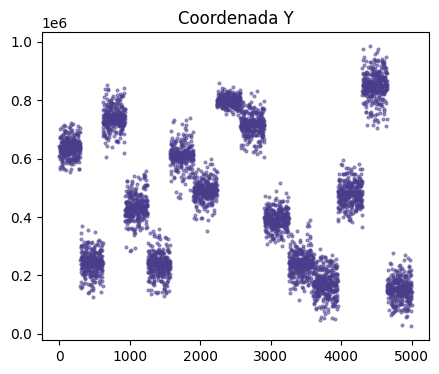

In [319]:
plt.figure(figsize=(5, 4))
plt.plot(X_cpu[:, 1], "o", markersize=2, alpha=0.5, color = "darkslateblue")
plt.title("Coordenada Y")
plt.show()

### `a.` **K-Means** con ganancias decrecientes para determinar K

In [320]:
from src.models import KMeans
from src.utils import find_elbow

##### $L$ vs. $K$

K =  1 → Inercia = 516864302744182.00
K =  2 → Inercia = 289934063974210.00
K =  3 → Inercia = 182617259354599.00
K =  4 → Inercia = 119781237770822.00
K =  5 → Inercia = 97158902693967.00
K =  6 → Inercia = 79352490290900.00
K =  7 → Inercia = 66442291574055.00
K =  8 → Inercia = 56002180572199.00
K =  9 → Inercia = 45039384213855.00
K = 10 → Inercia = 39506532259043.00
K = 11 → Inercia = 31693774488119.00
K = 12 → Inercia = 24877328816656.00
K = 13 → Inercia = 20833857832204.00
K = 14 → Inercia = 16848986287901.00
K = 15 → Inercia = 13279024047994.00
K = 16 → Inercia = 12878514745437.00
K = 17 → Inercia = 12533515534453.00
K = 18 → Inercia = 12190859497060.00
K = 19 → Inercia = 11827965038787.00

El mejor número de clusters según el método del codo es K = 15


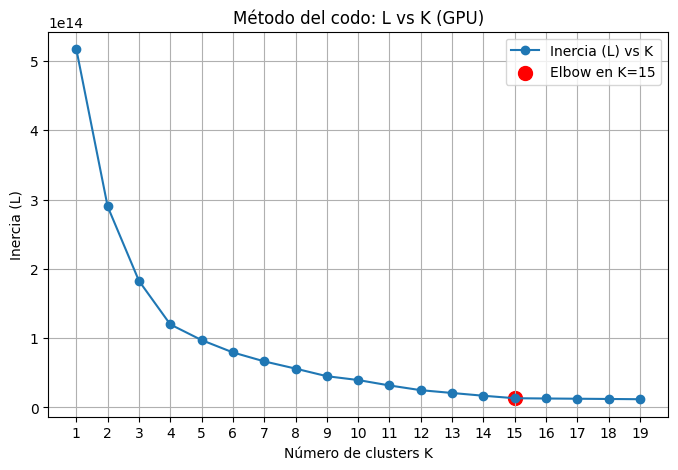

In [321]:


Ks = list(range(1, 20))
Ls = []
for K in Ks:
    km = KMeans(n_clusters=K, init="k-means++", n_init=10,
                max_iter=300, tol=1e-4, random_state=42)
    km.fit(X)
    print(f"K = {K:2d} → Inercia = {km.distortion_:.2f}")
    Ls.append(km.distortion_)

elbow_idx, distances = find_elbow(Ks, Ls, alpha = 0.0177)
bestK = Ks[elbow_idx]
bestL = Ls[elbow_idx]
print(f"\nEl mejor número de clusters según el método del codo es K = {bestK}")

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(Ks, Ls, marker='o', label='Inercia (L) vs K')
plt.scatter([bestK], [bestL], color='red', s=100, label=f'Elbow en K={bestK}')
plt.xlabel("Número de clusters K")
plt.ylabel("Inercia (L)")
plt.title("Método del codo: L vs K (GPU)")
plt.xticks(Ks)
plt.grid(True)
plt.legend()
plt.show()

In [322]:
km = KMeans(n_clusters=bestK, init="k-means++", n_init=10,
            max_iter=300, tol=1e-4, random_state=42)
labels = km.fit_predict(X)

print(f"Inercia final: {km.distortion_:.2f}")
print(f"Iteraciones en la mejor ejecución: {km.n_iter_}")

Inercia final: 13279024047994.00
Iteraciones en la mejor ejecución: 16


##### Gráfico del conjunto $x_i$

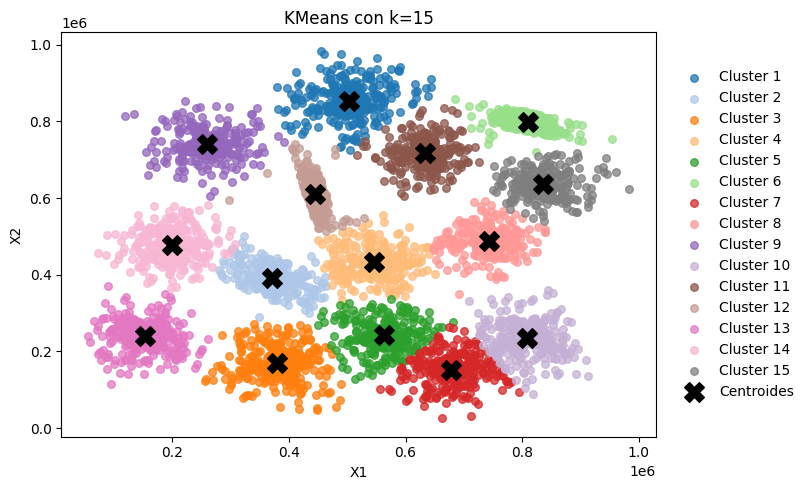

In [323]:
cmap = plt.get_cmap("tab20")
colors = [cmap(i) for i in range(20)]  # devuelve 20 RGBA distintos


fig, ax = plt.subplots(figsize=(11,5))
for k in range(km.n_clusters):
    pts_k = X[labels == k]
    x_k = pts_k[:, 0].get()
    y_k = pts_k[:, 1].get()
    ax.scatter(x_k, y_k, s=30, color=colors[k % 20], label=f"Cluster {k+1}", alpha=0.75)


centers = km.cluster_centers_
cx = centers[:, 0].get()
cy = centers[:, 1].get()
ax.scatter(cx, cy, marker='X', s=200, c='black', label="Centroides")

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_title(f"KMeans con k={km.n_clusters}")


ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, frameon=False)

plt.tight_layout(rect=(0,0,0.75,1))
plt.show()

### `b.`  Gaussian Mixture Model (**GMM**)

##### inicialización de GMM con una corrida de K-means

In [324]:
import matplotlib.pyplot as plt
from src.models import GMM

In [325]:
# 2) Inicializa parámetros con KMeans
km = KMeans(n_clusters=bestK, init="k-means++", n_init=10,
            max_iter=300, tol=1e-4, random_state=42)

labels_k = km.fit_predict(X)
means0 = km.cluster_centers_
counts = cp.bincount(labels_k, minlength=bestK).astype(cp.float64)
weights0 = counts / X.shape[0]
D = X.shape[1]
covs0 = cp.zeros((bestK, D, D), dtype=cp.float64)
for k in range(bestK):
    Xk = X[labels_k == k].astype(cp.float64)
    diff = Xk - means0[k]
    covs0[k] = (diff.T @ diff) / Xk.shape[0] + cp.eye(D, dtype=cp.float64)*1e-6


In [326]:
# 3) Crea y ajusta GMM usando esos init_params
init_params = {'means': means0, 'weights': weights0, 'covs': covs0}

gmm = GMM(n_components=bestK, tol=1e-4, max_iter=100,
            reg_covar=1e-6, random_state=42, init_params=init_params)
labels = gmm.fit_predict(X)
print(f"GMM final con K={bestK}: LL={gmm.log_likelihood_:.2f}, iter={gmm.n_iter_}")


GMM final con K=15: LL=-131948.36, iter=100


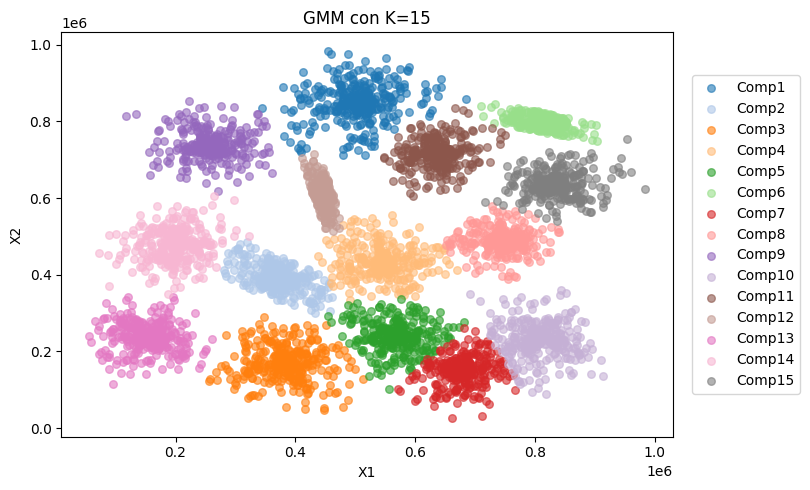

In [327]:
# 4) Graficar clusters GMM
cmap = plt.get_cmap("tab20")
colors = [cmap(i) for i in range(20)]
fig, ax = plt.subplots(figsize=(11,5))
for k in range(bestK):
    pts = X[labels == k]
    x = pts[:,0].get()
    y = pts[:,1].get()
    ax.scatter(x, y, s=30, color=colors[k], label=f"Comp{k+1}", alpha=0.6)
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_title(f"GMM con K={bestK}")
ax.legend(loc="center left", bbox_to_anchor=(1.02,0.5))
plt.tight_layout(rect=(0,0,0.75,1))
plt.show()

### `c.`  **DBSCAN**

In [340]:
from src.models import DBSCAN

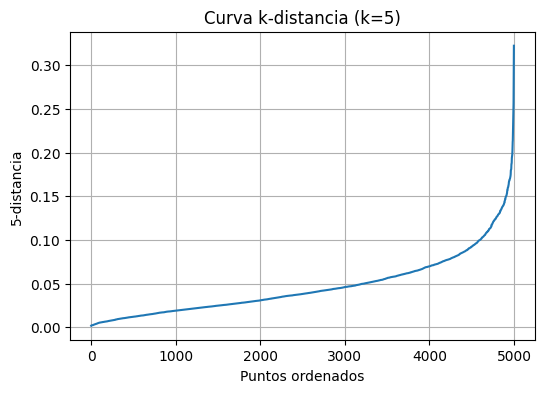

eps	min_s	clusters	noise
0.5	 5	 1		0
0.5	10	 1		0
0.5	15	 1		0
1.0	 5	 1		0
1.0	10	 1		0
1.0	15	 1		0
1.5	 5	 1		0


KeyboardInterrupt: 

In [ ]:

# X = cp.array(clustering_df.values, dtype=cp.float64)


X_cpu = clustering_df.values.astype(float)
X = cp.array(X_cpu)

# 2) Normalizar
mean = X.mean(axis=0)
std  = X.std(axis=0)
Xn = (X - mean) / std

# 3) Definir rejilla en GPU
eps_list = cp.linspace(0.0, 0.2, 10)                      # 10 valores de ε
min_pts_list = cp.linspace(30, 200, 10, dtype=cp.int32)   # 10 valores de min_samples

# 4) Iniciar arrays de resultados en GPU
clusters = cp.zeros((min_pts_list.size, eps_list.size), dtype=cp.int32)
noise    = cp.zeros_like(clusters)

# 5) Grid search
for i, min_pts in enumerate(min_pts_list):
    for j, eps in enumerate(eps_list):
        db = DBSCAN(eps=float(eps), min_samples=int(min_pts))
        labels = db.fit_predict(Xn)
        labels_cpu = labels.get()
        n_clusters = len(set(labels_cpu.tolist())) - (1 if -1 in labels_cpu else 0)
        n_noise    = int((labels_cpu == -1).sum())
        clusters[i, j] = n_clusters
        noise[i, j]    = n_noise

# 6) Preparar datos para plot (traer a CPU)
eps_cpu     = cp.asnumpy(eps_list)
min_pts_cpu = cp.asnumpy(min_pts_list)
clusters_cpu= cp.asnumpy(clusters)
noise_cpu   = cp.asnumpy(noise)

E, M = cp.meshgrid(eps_list, min_pts_list)
E_cpu = cp.asnumpy(E).flatten()
M_cpu = cp.asnumpy(M).flatten()

# 7) Graficar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sc1 = ax1.scatter(
    E_cpu, M_cpu,
    c=clusters_cpu.flatten(),
    cmap="PiYG_r",
    s=100,
    edgecolors="k"
)
ax1.set_title("Número de clusters detectados")
ax1.set_xlabel("ε (epsilon)")
ax1.set_ylabel("min_samples")
fig.colorbar(sc1, ax=ax1, label="Clusters")

sc2 = ax2.scatter(
    E_cpu, M_cpu,
    c=noise_cpu.flatten(),
    cmap="PiYG_r",
    s=100,
    edgecolors="k"
)
ax2.set_title("Cantidad de puntos de ruido")
ax2.set_xlabel("ε (epsilon)")
fig.colorbar(sc2, ax=ax2, label="Ruido")

plt.tight_layout()
plt.show()

##### Variación de los parámetros ε (radio de la vecindad) y $K$ (mínimo número de puntos en una zona densa)

##### Elección de una combinación de ε y K

##### Gráfico de los datos

## `2.` **Reducción de dimensionalidad**

##### Cargar los datos


In [ ]:
MNIST_path = "data/MNIST_dataset.csv"
MNIST_df = pd.read_csv(MNIST_path)

##### Visualización de ejemplo  

In [ ]:
MNIST_df.sample(5, random_state=SEED)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
46730,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
48393,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41416,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
34506,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
43725,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### `a.` **PCA**

##### Gráfico de cómo varía el error cuadrático medio de reconstrucción sobre el conjunto de datos en función de la cantidad de componentes principales utilizadas

### `b.` Selección de **componentes principales**

##### Gráfico de las imagenes de los digitos originales y reconstruidos para las primeras 10 muestras del dataset con ... cantidad de componentes

### `c.` Modelo de Autoencoder Variacional (**VAE**) usando PyTorch

##### División en entrenamiento y validación

##### Entrenamiento

##### Comparación con PCA